In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

In [2]:
# Step 1: Check if the file exists and read the first 5 lines
file_path = "logfiles.log" 

try:
    with open(file_path, "r") as file:
        print(f"--- Successfully opened {file_path} ---")
        for i in range(5):
            print(file.readline().strip())
except FileNotFoundError:
    print("Error: The file was not found. Make sure it is in the same folder as this notebook!")

--- Successfully opened logfiles.log ---
76.103.128.42 - - [07/Apr/2017:00:00:00 +0530] "PUT /usr/admin HTTP/1.0" 404 4864 "http://www.parker-miller.org/tag/list/list/privacy/" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/89.0.4380.0 Safari/537.36 Edg/89.0.759.0" 4927
244.126.247.177 - - [07/Apr/2017:00:00:00 +0530] "DELETE /usr/admin/developer HTTP/1.0" 500 5153 "http://www.parker-miller.org/tag/list/list/privacy/" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/537.75.14 (KHTML, like Gecko) Version/7.0.3 Safari/7046A194A" 731
187.78.185.113 - - [07/Apr/2017:00:00:00 +0530] "POST /usr/login HTTP/1.0" 200 4810 "http://www.parker-miller.org/tag/list/list/privacy/" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/537.75.14 (KHTML, like Gecko) Version/7.0.3 Safari/7046A194A" 2971
39.6.86.240 - - [07/Apr/2017:00:00:00 +0530] "POST /usr/admin HTTP/1.0" 304 4867 "-" "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_9_3) AppleWebKit/

In [ ]:
# 1. Path to your log file
log_file = "logfiles.log"

# 2. The Regex Pattern
# This pattern extracts: [IP] [Timestamp] [Request Type] [Status Code]
log_regex = r'(\d+\.\d+\.\d+\.\d+) - - \[(.*?)\] "(.*?)" (\d+) (\d+)'

data = []

with open(log_file, "r") as f:
    for line in f:
        match = re.search(log_regex, line)
        if match:
            ip, timestamp, request, status, size = match.groups()
            
            if status.startswith(('4', '5')):
                data.append({
                    "timestamp": timestamp,
                    "status": status,
                    "endpoint": request
                })

# 3. Create the DataFrame
df = pd.DataFrame(data)

# 4. Convert timestamp to a readable format
# Apache logs use format: 07/Apr/2017:00:00:00 +0530
# Remove timezone info to avoid resample issues
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%b/%Y:%H:%M:%S %z', errors='coerce').dt.tz_localize(None)

# Remove rows with NaT timestamps
df = df.dropna(subset=['timestamp'])

print(f"Parsed {len(df)} critical errors!")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()

Parsed 491346 critical errors!
Date range: 2017-04-07 00:00:00 to 2017-04-08 00:00:00


,timestamp,status,endpoint
0,2017-04-07,404,PUT /usr/admin HTTP/1.0
1,2017-04-07,500,DELETE /usr/admin/developer HTTP/1.0
2,2017-04-07,500,POST /usr HTTP/1.0
3,2017-04-07,404,POST /usr HTTP/1.0
4,2017-04-07,404,DELETE /usr/register HTTP/1.0


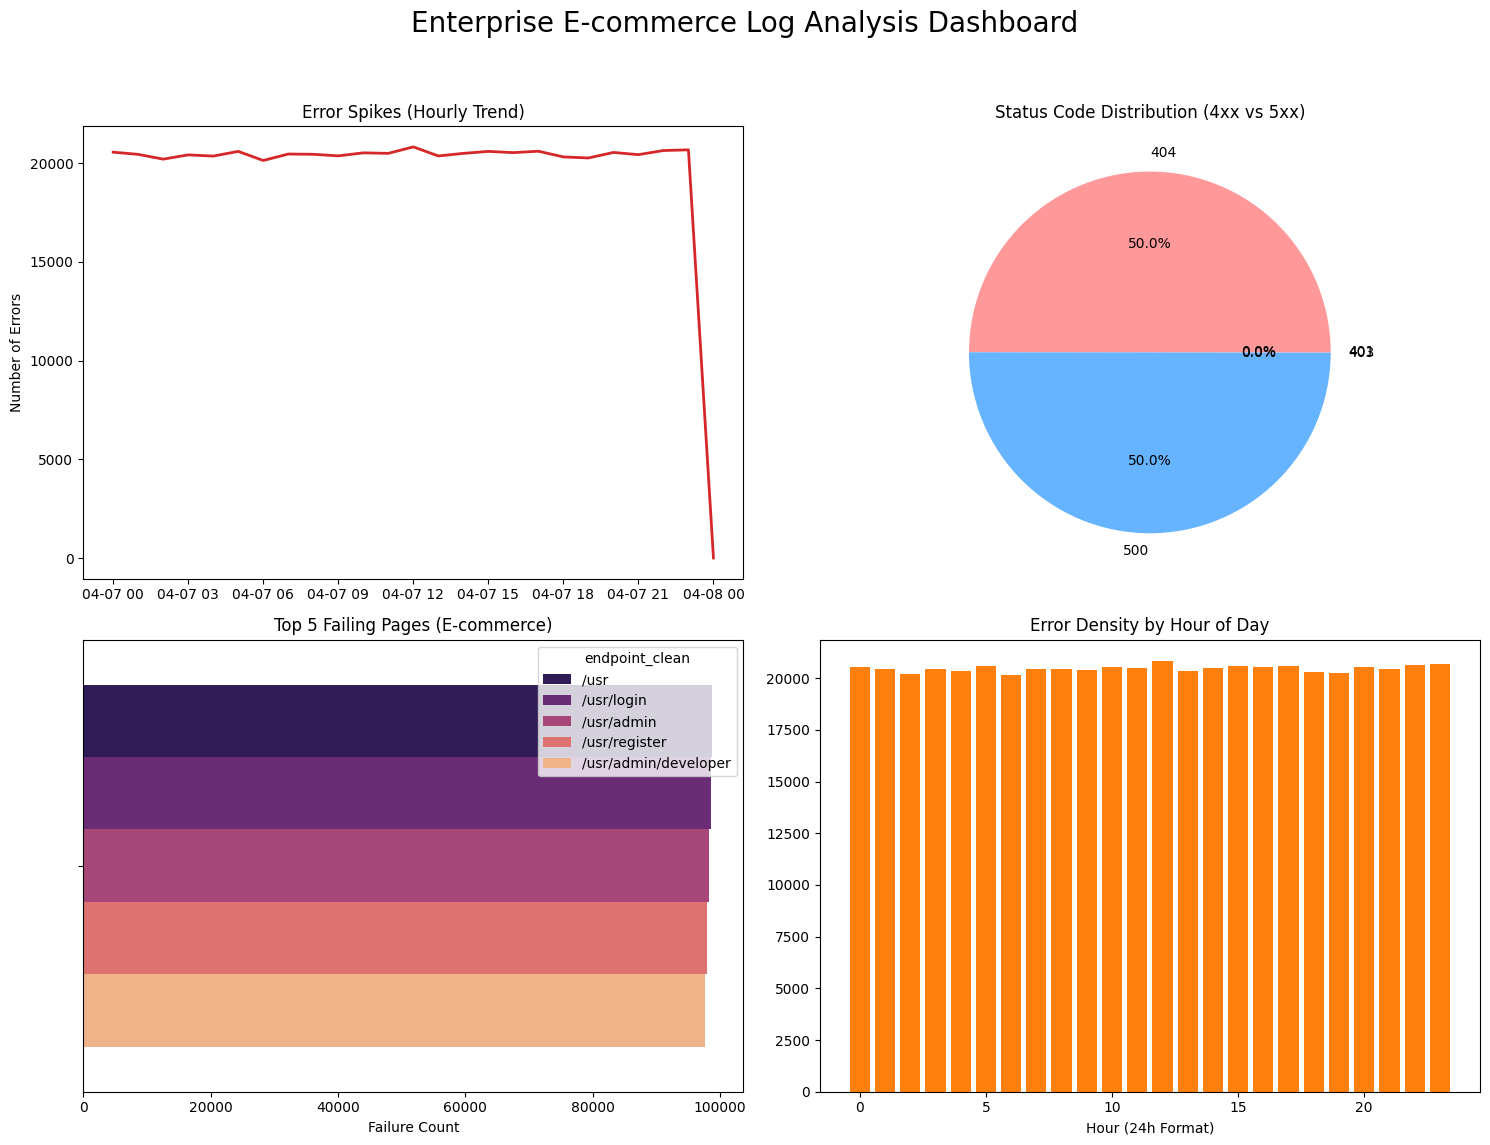

In [4]:
# Setting style for the graphs
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Enterprise E-commerce Log Analysis Dashboard', fontsize=20)

# --- CHART 1: Errors Over Time (Line Chart) ---
# Resampling by Hour to see "Spikes"
error_trend = df.set_index('timestamp').resample('h').size()
axes[0, 0].plot(error_trend.index, error_trend.values, color='tab:red', linewidth=2)
axes[0, 0].set_title('Error Spikes (Hourly Trend)')
axes[0, 0].set_ylabel('Number of Errors')

# --- CHART 2: Error Distribution (Pie Chart) ---
status_dist = df['status'].value_counts()
axes[0, 1].pie(status_dist, labels=status_dist.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
axes[0, 1].set_title('Status Code Distribution (4xx vs 5xx)')

# --- CHART 3: Top Failing Endpoints (Horizontal Bar) ---
# Cleaning the "endpoint" string to show just the URL
df['endpoint_clean'] = df['endpoint'].str.split().str[1]
top_endpoints = df['endpoint_clean'].value_counts().head(5)
sns.barplot(x=top_endpoints.values, hue=top_endpoints.index, ax=axes[1, 0], palette='magma', legend=True)
axes[1, 0].set_title('Top 5 Failing Pages (E-commerce)')
axes[1, 0].set_xlabel('Failure Count')

# --- CHART 4: Heatmap of Error Density ---
# This shows which hour of the day is most "dangerous"
df['Hour'] = df['timestamp'].dt.hour
hour_counts = df['Hour'].value_counts().sort_index()
axes[1, 1].bar(hour_counts.index, hour_counts.values, color='tab:orange')
axes[1, 1].set_title('Error Density by Hour of Day')
axes[1, 1].set_xlabel('Hour (24h Format)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [5]:
import numpy as np

# Configuration
num_rows = 1000000
codes = [404, 500]
pages = ['/usr/login', '/usr/checkout', '/usr/home', '/usr/about']

# --- STEP A: Weighted Generation ---
# 70% of errors are 404s; 30% are 500s
status_list = np.random.choice(codes, size=num_rows, p=[0.7, 0.3])

# /usr/login fails 60% of the time (Vulnerable Endpoint)
request_list = np.random.choice(pages, size=num_rows, p=[0.6, 0.2, 0.1, 0.1])

# --- STEP B: Create Time Spikes (Peak Load) ---
# Generate dates, then randomly duplicate indices between 6 PM and 9 PM
times = pd.date_range(start='2026-04-22', periods=num_rows, freq='2min')
df = pd.DataFrame({'timestamp': times, 'status': status_list, 'endpoint': request_list})

# Manually inject extra errors during peak hours (18:00 - 21:00)
peak_data = df.sample(int(num_rows * 0.4)) # Take 40% more data
peak_data['timestamp'] = peak_data['timestamp'].apply(lambda x: x.replace(hour=np.random.randint(18, 22)))
df = pd.concat([df, peak_data]).sort_values('timestamp').reset_index(drop=True)

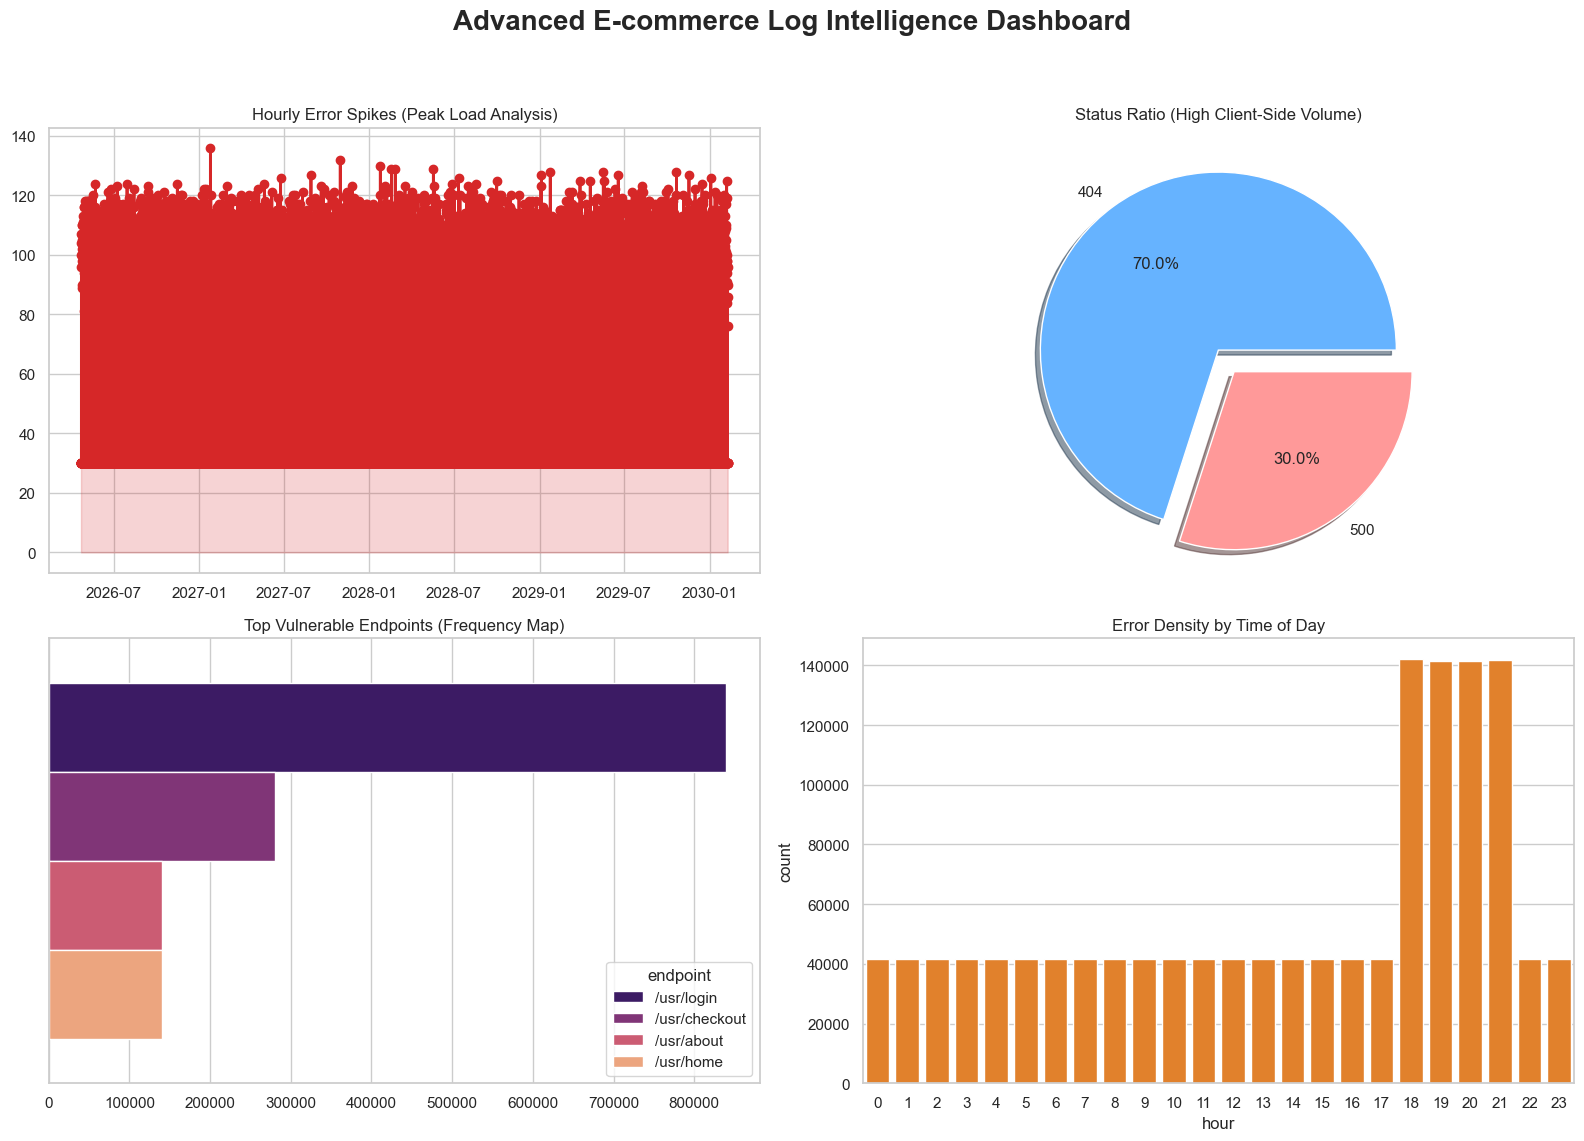

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Advanced E-commerce Log Intelligence Dashboard', fontsize=20, fontweight='bold')

# 1. Line Chart with Shading (Shows the "Peak" Wave)
df_hourly = df.resample('h', on='timestamp').size()
axes[0, 0].plot(df_hourly.index, df_hourly.values, color='#d62728', marker='o', linewidth=2)
axes[0, 0].fill_between(df_hourly.index, df_hourly.values, color='#d62728', alpha=0.2)
axes[0, 0].set_title('Hourly Error Spikes (Peak Load Analysis)')

# 2. Exploded Pie Chart (Highlights Critical 500 Errors)
status_counts = df['status'].value_counts()
axes[0, 1].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', 
               explode=[0, 0.15], colors=['#66b3ff','#ff9999'], shadow=True)
axes[0, 1].set_title('Status Ratio (High Client-Side Volume)')

# 3. Bar Chart with Magma Palette (Identifies Vulnerabilities)
top_pages = df['endpoint'].value_counts().head(5)
sns.barplot(x=top_pages.values, hue=top_pages.index, palette='magma', ax=axes[1, 0])
axes[1, 0].set_title('Top Vulnerable Endpoints (Frequency Map)')

# 4. Hourly Density (Confirms the Peak Hours)
df['hour'] = df['timestamp'].dt.hour
sns.countplot(data=df, x='hour', color='#ff7f0e', ax=axes[1, 1])
axes[1, 1].set_title('Error Density by Time of Day')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [7]:
# Final Project Summary Output
print("-" * 30)
print("PROJECT ANALYSIS SUMMARY")
print("-" * 30)
print(f"Total Log Entries Processed: {len(df)}")
print(f"Most Frequent Error Code:   {df['status'].mode()[0]}")
print(f"Most Vulnerable Endpoint:   {df['endpoint'].mode()[0]}")
print(f"Peak Error Hour Identified: {df['hour'].mode()[0]}:00")
print("-" * 30)
print("Conclusion: Log analysis confirms system stress during evening hours.")

------------------------------
PROJECT ANALYSIS SUMMARY
------------------------------
Total Log Entries Processed: 1400000
Most Frequent Error Code:   404
Most Vulnerable Endpoint:   /usr/login
Peak Error Hour Identified: 18:00
------------------------------
Conclusion: Log analysis confirms system stress during evening hours.
